In [1]:
# Colab-safe dependency bootstrap. Re-running is harmless.
import importlib, subprocess, sys

def _ensure(requirements):
    missing = []
    for module_name, pip_spec in requirements:
        try:
            importlib.import_module(module_name)
        except ImportError:
            missing.append(pip_spec)
    if missing:
        print("Installing:", " ".join(missing))
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
    else:
        print("All dependencies already present.")

_ensure([
    ("qiskit",     "qiskit>=2.1"),
    ("qiskit_aer", "qiskit-aer>=0.15"),
    ("numpy",      "numpy"),
    ("scipy",      "scipy"),
    ("matplotlib", "matplotlib"),
    ("pylatexenc", "pylatexenc"),      # nicer circuit drawings
])

All dependencies already present.


In [2]:
from __future__ import annotations

import json
import os
import time
from dataclasses import dataclass
from typing import Iterable, Mapping, Sequence

import matplotlib.pyplot as plt
import numpy as np
import qiskit
import qiskit_aer
import scipy
from scipy.linalg import eigvals, hankel, lstsq, svd

from qiskit import ClassicalRegister, QuantumCircuit, QuantumRegister, transpile
from qiskit.circuit import Gate
from qiskit.circuit.library import PauliEvolutionGate, UnitaryGate
from qiskit.quantum_info import (
    Operator, SparsePauliOp, Statevector, partial_trace,
)
from qiskit.synthesis import SuzukiTrotter
from qiskit_aer import AerSimulator

print(f"qiskit      {qiskit.__version__}")
print(f"qiskit-aer  {qiskit_aer.__version__}")
print(f"numpy       {np.__version__}")
print(f"scipy       {scipy.__version__}")

_major, _minor = (int(x) for x in qiskit.__version__.split(".")[:2])
assert (_major, _minor) >= (2, 1), "This notebook targets Qiskit >= 2.1 (control-flow / primitives API)."

qiskit      2.5.1
qiskit-aer  0.17.2
numpy       2.4.6
scipy       1.17.1


In [3]:
# ----------------------------------------------------------------- experiment budget
BUDGET = "full"        # "full" = official benchmark. "fast" = half the shots, for debugging.

if BUDGET == "full":
    N_TIMES, DT, SHOTS = 64, 0.2, 2000          # official challenge budget: 256,000 shots
elif BUDGET == "fast":
    N_TIMES, DT, SHOTS = 32, 0.4, 2000          # T_max 12.4 (vs 12.6), half the shots, ~2x faster
else:
    raise ValueError(BUDGET)

SEED = 2026            # master seed -- EVERY random draw in this notebook derives from it
STRICT_CHECKS = True   # checkpoints raise on failure (set False to keep going and inspect)

TS = np.arange(N_TIMES) * DT
T_MAX = TS[-1]

print(f"budget            : {BUDGET}")
print(f"times             : N_t = {N_TIMES}, dt = {DT}, T_max = {T_MAX:.2f}")
print(f"shots per (t,phi) : {SHOTS}")
print(f"total shots       : {N_TIMES * 2 * SHOTS:,}")
print(f"Fourier resolution: 2*pi/T_max = {2 * np.pi / T_MAX:.3f}")
print(f"Nyquist window    : |E| <= pi/dt = {np.pi / DT:.2f}")
if BUDGET != "full":
    print("\nNOTE: reduced budget. Checks whose tolerance was calibrated at the official budget")
    print("      become ADVISORY; deterministic checks stay hard. Re-run at 'full' before you")
    print("      believe any number you intend to report.")

budget            : full
times             : N_t = 64, dt = 0.2, T_max = 12.60
shots per (t,phi) : 2000
total shots       : 256,000
Fourier resolution: 2*pi/T_max = 0.499
Nyquist window    : |E| <= pi/dt = 15.71


In [4]:
# ------------------------------------------------------------------- house style + checks
COL = {"blue": "#2a78d6", "orange": "#eb6834", "aqua": "#1baf7a", "violet": "#4a3aa7",
       "ink": "#0b0b0b", "muted": "#898781", "grid": "#e1e0d9", "axis": "#c3c2b7"}
BG = "#fcfcfb"

def style_axes(ax):
    """One consistent look for every figure in the notebook."""
    ax.set_facecolor(BG)
    ax.grid(True, color=COL["grid"], linewidth=0.8)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color(COL["axis"])
    ax.tick_params(colors=COL["muted"], labelsize=9)
    ax.xaxis.label.set_color(COL["ink"])
    ax.yaxis.label.set_color(COL["ink"])
    ax.title.set_color(COL["ink"])

plt.rcParams.update({"figure.facecolor": BG, "savefig.facecolor": BG, "figure.dpi": 110})

FIGDIR = "figures"          # every figure is written here as well as displayed
os.makedirs(FIGDIR, exist_ok=True)

def show(fig, name: str):
    """Display a figure AND save it -- §10.1 asks for these plots as deliverables."""
    fig.savefig(f"{FIGDIR}/{name}.png", dpi=200, bbox_inches="tight")
    plt.show()


CHECK_LOG: list[tuple[str, bool, str, bool]] = []

def check(name: str, ok: bool, detail: str = "", soft: bool = False,
          budget_sensitive: bool = False) -> bool:
    """Record and report a checkpoint.

    soft=True             ADVISORY always: reported, never raises. Used for quantities that are
                          genuinely stochastic run to run (the Krylov GEVP is the honest example).
    budget_sensitive=True ADVISORY only when BUDGET != "full", because the tolerance was
                          calibrated at the official shot budget.

    Deterministic checks -- conventions, bit ordering, operator identities -- are neither, so
    they stay HARD at every budget. A green notebook at BUDGET="fast" still proves your circuit
    and your endianness are right; it does not prove your statistics.
    """
    ok = bool(ok)
    soft = soft or (budget_sensitive and BUDGET != "full")
    CHECK_LOG.append((name, ok, detail, soft))
    tag = "PASS" if ok else ("warn" if soft else "FAIL")
    print(f"{tag:>4}  |  {name}" + (f"   ({detail})" if detail else ""))
    if not ok and not soft and STRICT_CHECKS:
        raise AssertionError(f"checkpoint failed: {name} {detail}")
    return ok


def sub_seed(tag: str, index: int = 0) -> int:
    """A reproducible, well-separated seed for `tag`, derived from the master SEED.

    Note we use zlib.crc32, NOT Python's hash(): hash() of a str is randomised per process
    (PYTHONHASHSEED), which would silently destroy reproducibility between runs.
    """
    import zlib
    entropy = [SEED, zlib.crc32(tag.encode()) % (2 ** 31), index]
    return int(np.random.SeedSequence(entropy).generate_state(1)[0]) % (2 ** 31)

def sigma_gate(estimate: float, reference: float, sem: float, n_sigma: float = 5.0):
    """Standard acceptance test used throughout: |est - ref| < n_sigma * sem."""
    dev = abs(estimate - reference)
    z = dev / sem if sem > 0 else np.inf
    return z < n_sigma, f"{estimate:+.4f} vs {reference:+.4f}, {z:.1f} sigma"

print("style + checkpoint helpers ready")

style + checkpoint helpers ready


In [5]:
N_SYS = 3                       # system qubits; the ancilla is one extra qubit (index N_SYS)
PHI_RE, PHI_IM = 0.0, -np.pi / 2   # the two quadrature settings

PAULI_CODES = {"X": 0, "Y": 1, "Z": 2}
CODE_TO_PAULI = "XYZ"


def benchmark_hamiltonian() -> SparsePauliOp:
    """H = 0.65 sum (XX + YY) + 0.25 sum ZZ + 0.40 Z0 - 0.50 Z1 + 0.15 Z2 (open chain)."""
    terms = []
    for i in range(N_SYS - 1):
        terms += [("XX", [i, i + 1], 0.65), ("YY", [i, i + 1], 0.65), ("ZZ", [i, i + 1], 0.25)]
    terms += [("Z", [0], 0.40), ("Z", [1], -0.50), ("Z", [2], 0.15)]
    return SparsePauliOp.from_sparse_list(terms, num_qubits=N_SYS).simplify()


def conserved_charge() -> SparsePauliOp:
    """Q = Z_0 + Z_1 + Z_2, the total magnetisation.  [H, Q] = 0."""
    return SparsePauliOp.from_sparse_list(
        [("Z", [j], 1.0) for j in range(N_SYS)], num_qubits=N_SYS)


def state_prep_circuit() -> QuantumCircuit:
    """|psi> = Ry(1.3) on qubit 0, applied to |000>."""
    qc = QuantumCircuit(N_SYS, name="prep")
    qc.ry(1.3, 0)
    return qc


HAM = benchmark_hamiltonian()
CHARGE = conserved_charge()
Z0_OBS = SparsePauliOp.from_sparse_list([("Z", [0], 1.0)], num_qubits=N_SYS)   # NOT conserved

print("H =", HAM)
print()
print("Q =", CHARGE)

H = SparsePauliOp(['IXX', 'IYY', 'IZZ', 'XXI', 'YYI', 'ZZI', 'IIZ', 'IZI', 'ZII'],
              coeffs=[ 0.65+0.j,  0.65+0.j,  0.25+0.j,  0.65+0.j,  0.65+0.j,  0.25+0.j,
  0.4 +0.j, -0.5 +0.j,  0.15+0.j])

Q = SparsePauliOp(['IIZ', 'IZI', 'ZII'],
              coeffs=[1.+0.j, 1.+0.j, 1.+0.j])


In [6]:
def exact_state(prep: QuantumCircuit | None = None) -> np.ndarray:
    return np.asarray(Statevector(prep if prep is not None else state_prep_circuit()).data)


@dataclass
class ExactSpectrum:
    """Symmetry-resolved exact eigensystem of (H, Q) plus the populations of |psi>."""
    energies: np.ndarray      # (2**n,)
    charges: np.ndarray       # (2**n,) integer Q labels
    populations: np.ndarray   # (2**n,) p_k = |<E_k, q_k | psi>|^2

    def populated(self, threshold: float = 1e-10):
        m = self.populations > threshold
        return self.energies[m], self.charges[m], self.populations[m]


def exact_spectrum(ham=None, charge=None, psi=None) -> ExactSpectrum:
    """Block-diagonalise H inside each Q sector -> a common (H, Q) eigenbasis."""
    ham = ham if ham is not None else HAM
    charge = charge if charge is not None else CHARGE
    psi = psi if psi is not None else exact_state()
    hmat = ham.to_matrix()
    qdiag = np.real(np.diag(charge.to_matrix()))
    energies, charges, pops = [], [], []
    for q in sorted(set(np.round(qdiag).astype(int))):
        idx = np.where(np.round(qdiag).astype(int) == q)[0]
        evals, evecs = np.linalg.eigh(hmat[np.ix_(idx, idx)])
        amps = evecs.conj().T @ psi[idx]
        energies += list(evals)
        charges += [q] * len(idx)
        pops += list(np.abs(amps) ** 2)
    order = np.argsort(energies)
    return ExactSpectrum(np.array(energies)[order],
                         np.array(charges)[order],
                         np.array(pops)[order])


def exact_unitary(ham: SparsePauliOp, t: float) -> np.ndarray:
    """U(t) = exp(-i H t) by eigendecomposition (exact for any t)."""
    evals, evecs = np.linalg.eigh(ham.to_matrix())
    return (evecs * np.exp(-1j * evals * t)) @ evecs.conj().T


def exact_chi(ham, psi, ts) -> np.ndarray:
    """chi(t) = <psi| e^{-iHt} |psi> = sum_k p_k e^{-i E_k t}."""
    evals, evecs = np.linalg.eigh(ham.to_matrix())
    p = np.abs(evecs.conj().T @ psi) ** 2
    return np.exp(-1j * np.outer(np.asarray(ts), evals)) @ p


def exact_chi_O(ham, psi, obs: SparsePauliOp, ts) -> np.ndarray:
    """chi_O(t) = Tr[O U(t) |psi><psi|] = <psi| O U(t) |psi>."""
    evals, evecs = np.linalg.eigh(ham.to_matrix())
    phi_o = obs.to_matrix().conj().T @ psi          # O is Hermitian
    weights = np.conj(evecs.conj().T @ phi_o) * (evecs.conj().T @ psi)
    return np.exp(-1j * np.outer(np.asarray(ts), evals)) @ weights


def exact_system_marginal_expectation(ham, psi, obs: SparsePauliOp, t: float) -> float:
    """Tr[O rho^(I)(t)] with rho^(I) = (rho + U rho U^dag)/2  -- Eq. (D1)."""
    psi_t = exact_unitary(ham, t) @ psi
    omat = obs.to_matrix()
    return float(0.5 * np.real(psi.conj() @ omat @ psi + psi_t.conj() @ omat @ psi_t))


PSI = exact_state()
SPEC = exact_spectrum()
E_EXACT, Q_EXACT_LABELS, P_EXACT = SPEC.populated(1e-6)

H_EXPECT_EXACT = float(np.real(PSI.conj() @ HAM.to_matrix() @ PSI))
Q_EXPECT_EXACT = float(np.real(PSI.conj() @ CHARGE.to_matrix() @ PSI))

print("Populated levels of |psi>  (these are the four lines you must recover):\n")
print("      E_k        q_k       p_k")
for e, q, p in zip(E_EXACT, Q_EXACT_LABELS, P_EXACT):
    print(f"   {e:+9.4f}   {q:+4d}    {p:.4f}")
print(f"\n<H> = {H_EXPECT_EXACT:+.6f}      <Q> = {Q_EXPECT_EXACT:+.6f}")
print(f"full spectral radius   = {np.max(np.abs(SPEC.energies)):.3f}")
print(f"populated-line radius  = {np.max(np.abs(E_EXACT)):.3f}")
print(f"min populated spacing  = {np.min(np.diff(np.sort(E_EXACT))):.3f}")

Populated levels of |psi>  (these are the four lines you must recover):

      E_k        q_k       p_k
     -1.9152     +1    0.1597
     -0.4810     +1    0.1527
     +0.5500     +3    0.6337
     +1.9463     +1    0.0538

<H> = +0.073874      <Q> = +2.267499
full spectral radius   = 2.635
populated-line radius  = 1.946
min populated spacing  = 1.031


In [7]:
# ---------------------------------------------------- CHECKPOINT 2: the model is what we claim
h_mat, q_mat = HAM.to_matrix(), CHARGE.to_matrix()

check("[H, Q] = 0 exactly",
      np.linalg.norm(h_mat @ q_mat - q_mat @ h_mat) < 1e-12,
      f"||[H,Q]|| = {np.linalg.norm(h_mat @ q_mat - q_mat @ h_mat):.2e}")

check("populations sum to 1",
      np.isclose(SPEC.populations.sum(), 1.0, atol=1e-10))

check("exactly four populated levels", len(E_EXACT) == 4, f"got {len(E_EXACT)}")

check("populated sectors are {+1, +3}",
      set(np.round(Q_EXACT_LABELS).astype(int)) == {1, 3})

check("|000> is an exact eigenstate at E = 0.55",
      np.isclose(E_EXACT[np.round(Q_EXACT_LABELS).astype(int) == 3][0], 0.55, atol=1e-12))

check("Q=3 weight equals cos^2(0.65)",
      np.isclose(P_EXACT[np.round(Q_EXACT_LABELS).astype(int) == 3].sum(),
                 np.cos(0.65) ** 2, atol=1e-10),
      f"{P_EXACT[np.round(Q_EXACT_LABELS).astype(int) == 3].sum():.6f}")

check("no aliasing at this dt",
      np.max(np.abs(SPEC.energies)) < np.pi / DT,
      f"radius {np.max(np.abs(SPEC.energies)):.2f} < Nyquist {np.pi / DT:.2f}")

check("populated lines are Fourier-resolvable",
      np.min(np.diff(np.sort(E_EXACT))) > 2 * np.pi / T_MAX,
      f"spacing {np.min(np.diff(np.sort(E_EXACT))):.2f} > resolution {2 * np.pi / T_MAX:.2f}")

PASS  |  [H, Q] = 0 exactly   (||[H,Q]|| = 0.00e+00)
PASS  |  populations sum to 1
PASS  |  exactly four populated levels   (got 4)
PASS  |  populated sectors are {+1, +3}
PASS  |  |000> is an exact eigenstate at E = 0.55
PASS  |  Q=3 weight equals cos^2(0.65)   (0.633749)
PASS  |  no aliasing at this dt   (radius 2.64 < Nyquist 15.71)
PASS  |  populated lines are Fourier-resolvable   (spacing 1.03 > resolution 0.50)


True

In [8]:
def build_controlled_evolution(ham: SparsePauliOp, t: float,
                               method: str = "exact", reps: int = 2) -> Gate:
    """Controlled-U(t) whose FIRST qubit is the ancilla control.

    method="exact"   : the block unitary |0><0| (x) I + |1><1| (x) e^{-iHt}, built numerically.
                       Simulator-only, zero Trotter error -- use this for validation.
    method="trotter" : synthesise the 2nd-order Suzuki-Trotter product formula FIRST, then
                       control the whole synthesised circuit.  Hardware-realistic.

    Append with:  qc.append(gate, [ancilla, sys_0, ..., sys_{n-1}]).
    """
    n = ham.num_qubits

    if method == "exact":
        from scipy.linalg import expm
        u = expm(-1j * ham.to_matrix() * t)
        d = 2 ** n
        p0, p1 = np.diag([1.0, 0.0]), np.diag([0.0, 1.0])
        # qargs = [anc, s0, ..., s_{n-1}] -> ancilla is the LOWEST matrix bit
        cu = np.kron(np.eye(d), p0) + np.kron(u, p1)
        return UnitaryGate(cu, label=f"c-U(exact,t={t:.3g})")

    elif method == "trotter":
        evo = PauliEvolutionGate(ham, time=t, synthesis=SuzukiTrotter(order=2, reps=reps))
        uncontrolled = QuantumCircuit(n)
        uncontrolled.append(evo, range(n))
        uncontrolled = transpile(uncontrolled, basis_gates=["rz", "sx", "x", "cx"],
                                 optimization_level=1, seed_transpiler=0)
        # synthesise FIRST, control SECOND -- controlling the already-synthesised circuit
        # keeps the ancilla branch |0><0|(x)I + |1><1|(x)U_trot exact.
        return uncontrolled.to_gate(label=f"cU_trot(t={t:.3g},r={reps})").control(1)

    else:
        raise ValueError(f"unknown method {method!r}")

Trotter reps=1 -- as built : depth   5   {'h': 4, 'measure': 4, 'ry': 1, 'ccircuit-54': 1, 'p': 1, 'sdg': 1}
               -- transpiled: depth 664   294 CX   (this is the number that matters)


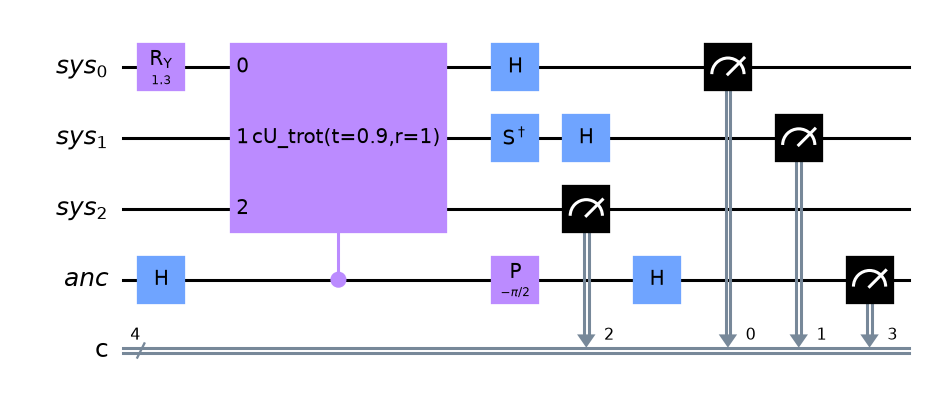

In [9]:
def build_shadow_hadamard_circuit(ham: SparsePauliOp, t: float, phi: float,
                                  basis: Sequence[int] | None,
                                  prep: QuantumCircuit | None = None,
                                  method: str = "exact", reps: int = 2,
                                  measure: bool = True) -> QuantumCircuit:
    """Hadamard test + randomised local-Pauli measurement of the system register."""
    n = ham.num_qubits
    prep = prep if prep is not None else state_prep_circuit()
    sys_reg = QuantumRegister(n, "sys")
    anc_reg = QuantumRegister(1, "anc")
    qc = QuantumCircuit(sys_reg, anc_reg)

    qc.compose(prep, qubits=sys_reg, inplace=True)          # |psi>
    qc.h(anc_reg[0])                                        # ancilla -> |+>
    qc.append(build_controlled_evolution(ham, t, method, reps), [anc_reg[0], *sys_reg])
    if phi != 0.0:
        qc.p(phi, anc_reg[0])                               # quadrature selector
    qc.h(anc_reg[0])                                        # interfere

    if basis is not None:                                   # shadow basis rotation
        for j, b in enumerate(basis):
            if b == 0:            # X basis
                qc.h(sys_reg[j])
            elif b == 1:          # Y basis
                qc.sdg(sys_reg[j])
                qc.h(sys_reg[j])
            # b == 2 (Z basis): nothing to do

    if measure:
        creg = ClassicalRegister(n + 1, "c")
        qc.add_register(creg)
        for j in range(n):
            qc.measure(sys_reg[j], creg[j])                 # c[j] <- system qubit j
        qc.measure(anc_reg[0], creg[n])                     # c[n] <- ancilla
    return qc


demo = build_shadow_hadamard_circuit(HAM, 0.9, PHI_IM, basis=[0, 1, 2], method="trotter", reps=1)
_demo_t = transpile(demo, basis_gates=["rz", "sx", "x", "cx"], optimization_level=1,
                    seed_transpiler=0)
print(f"Trotter reps=1 -- as built : depth {demo.depth():3d}   {dict(demo.count_ops())}")
print(f"               -- transpiled: depth {_demo_t.depth():3d}   "
      f"{_demo_t.count_ops().get('cx', 0)} CX   (this is the number that matters)")

# §10.1 asks for circuit diagrams of BOTH quadratures -- save them while we are here
for _name, _phi in (("phi_0_real", PHI_RE), ("phi_-pi2_imag", PHI_IM)):
    _f = build_shadow_hadamard_circuit(HAM, 0.9, _phi, basis=[0, 1, 2],
                                       method="trotter", reps=1).draw("mpl", fold=-1,
                                                                      style="clifford")
    _f.savefig(f"{FIGDIR}/03_circuit_{_name}.png", dpi=200, bbox_inches="tight")
    plt.close(_f)

demo.draw("mpl", fold=-1, style="clifford")

In [10]:

from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2

_service = QiskitRuntimeService()
T_HW, BASIS_HW, SHOTS_HW = 0.9, [0, 1, 2], 2000

# R008 already covers trotter+marrakesh; submit the other three arms
ARMS = [("exact",   "ibm_kingston"),
        ("exact",   "ibm_marrakesh"),
        ("trotter", "ibm_kingston")]

submitted = []
for method, bname in ARMS:
    backend = _service.backend(bname)
    circs = [build_shadow_hadamard_circuit(HAM, T_HW, phi, basis=BASIS_HW,
                                           method=method, reps=1)
             for phi in (PHI_RE, PHI_IM)]
    isa = transpile(circs, backend=backend, optimization_level=1,
                    seed_transpiler=sub_seed("hw-transpile"))
    ops = isa[0].count_ops()
    twoq = sum(v for k, v in ops.items() if k in ("cz", "cx", "ecr"))
    job = SamplerV2(mode=backend).run(isa, shots=SHOTS_HW)
    rec = dict(method=method, backend=bname, job_id=job.job_id(),
               depth=int(isa[0].depth()), two_q=int(twoq),
               status=str(job.status()), pending=int(backend.status().pending_jobs))
    submitted.append(rec)
    print(f"{method:>8} + {bname:14s} : depth {rec['depth']:5d}  2q {twoq:4d}  "
          f"job {rec['job_id']}  ({rec['status']}, {rec['pending']} queued)")

with open("/tmp/qh26_scratch/hw_2x2_jobs.json", "w") as fh:
    json.dump(submitted, fh, indent=2)
print("\nwrote hw_2x2_jobs.json")
print("\nreference arm already held: trotter + ibm_marrakesh = d9u95vs98n5s7392iao0 "
      "(depth 1729, 435 CZ, damping 0.179)")


   exact + ibm_kingston   : depth   375  2q  101  job d9ujlb0u5hac73ahadu0  (QUEUED, 16 queued)


   exact + ibm_marrakesh  : depth   375  2q  101  job d9ujlc0u5hac73ahadvg  (QUEUED, 22 queued)


 trotter + ibm_kingston   : depth  1729  2q  435  job d9ujld498n5s7392uqeg  (QUEUED, 17 queued)

wrote hw_2x2_jobs.json

reference arm already held: trotter + ibm_marrakesh = d9u95vs98n5s7392iao0 (depth 1729, 435 CZ, damping 0.179)
